# Feature Importance Analysis - Dataset DoS (MQTT Under Attack)

Este notebook realiza a **avaliação de importância das features** do dataset DoS usando técnicas de Machine Learning:

- **Random Forest Feature Importance**
- **XGBoost Feature Importance**  
- **Permutation Importance**



## 1. Importar Bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.inspection import permutation_importance

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost não está instalado. Instale com: pip install xgboost")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

print("✅ Bibliotecas carregadas com sucesso!")

⚠️ XGBoost não está instalado. Instale com: pip install xgboost
✅ Bibliotecas carregadas com sucesso!


## 2. Carregar e Explorar o Dataset DoS

In [3]:
# Carregar o dataset DoS
dos_path = Path("../data/raw/MQTT Under Attack Dataset/DoS.csv")
df = pd.read_csv(dos_path)

print(f"📊 Shape do dataset: {df.shape}")
print(f"📝 Colunas: {df.shape[1]}")
print(f"📋 Registros: {df.shape[0]}")
print(f"\n🏷️ Distribuição do Label ('type'):")
print(df['type'].value_counts())

📊 Shape do dataset: (94625, 67)
📝 Colunas: 67
📋 Registros: 94625

🏷️ Distribuição do Label ('type'):
type
normal    49111
DoS       45514
Name: count, dtype: int64


## 3. Pré-processamento dos Dados

In [4]:
# Selecionar apenas features numéricas
num_df = df.select_dtypes(include=['int64', 'float64'])

# Colunas a remover (irrelevantes para detecção de ataques)
colunas_para_remover = [
    'frame.time_delta_displayed', 'frame.time_epoch', 'frame.time_invalid', 
    'frame.time_relative', 'tcp.srcport', 'tcp.dstport', 
    'frame.coloring_rule.name', 'frame.coloring_rule.string', 
    'frame.comment', 'frame.comment.expert', 'frame.encap_type', 
    'frame.file_off', 'frame.ignored', 'frame.incomplete', 
    'frame.interface_id', 'frame.interface_name', 'frame.link_nr', 
    'frame.marked', 'frame.md5_hash', 'frame.number', 'frame.offset_shift',
    'mqtt.msgid', 'mqtt.username', 'mqtt.passwd', 
    'mqtt.willmsg', 'mqtt.willtopic'
]

# Remover colunas existentes no dataframe
colunas_existentes = [c for c in colunas_para_remover if c in num_df.columns]
num_df_clean = num_df.drop(columns=colunas_existentes, errors='ignore')

print(f"✅ Colunas numéricas após limpeza: {num_df_clean.shape[1]}")
print(f"📋 Features disponíveis:\n{list(num_df_clean.columns)}")

✅ Colunas numéricas após limpeza: 29
📋 Features disponíveis:
['frame.time_delta', 'frame.cap_len', 'frame.len', 'mqtt.clientid_len', 'mqtt.conack.flags.reserved', 'mqtt.conack.flags.sp', 'mqtt.conack.val', 'mqtt.conflag.cleansess', 'mqtt.conflag.passwd', 'mqtt.conflag.qos', 'mqtt.conflag.reserved', 'mqtt.conflag.retain', 'mqtt.conflag.uname', 'mqtt.conflag.willflag', 'mqtt.dupflag', 'mqtt.kalive', 'mqtt.len', 'mqtt.msgtype', 'mqtt.passwd_len', 'mqtt.proto_len', 'mqtt.qos', 'mqtt.retain', 'mqtt.sub.qos', 'mqtt.suback.qos', 'mqtt.topic_len', 'mqtt.username_len', 'mqtt.ver', 'mqtt.willmsg_len', 'mqtt.willtopic_len']


In [5]:
# Preparar X (features) e y (target)
X = num_df_clean.copy()

# Tratar valores ausentes
X = X.fillna(0)

# Substituir infinitos por valores grandes
X = X.replace([np.inf, -np.inf], 0)

# Encode do label (target)
le = LabelEncoder()
y = le.fit_transform(df['type'])

print(f"🎯 Classes: {le.classes_}")
print(f"📊 Shape X: {X.shape}")
print(f"📊 Shape y: {y.shape}")

# Verificar valores ausentes
print(f"\n⚠️ Valores ausentes por coluna:")
print(X.isnull().sum().sum())

🎯 Classes: ['DoS' 'normal']
📊 Shape X: (94625, 29)
📊 Shape y: (94625,)

⚠️ Valores ausentes por coluna:
0


In [6]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"📚 Treino: {X_train.shape[0]} amostras")
print(f"🧪 Teste: {X_test.shape[0]} amostras")

📚 Treino: 66237 amostras
🧪 Teste: 28388 amostras


## 4. Feature Importance com Random Forest

O Random Forest calcula a importância das features baseado na **redução média de impureza (Gini)** ao longo de todas as árvores.

In [7]:
# Treinar Random Forest
print("🌲 Treinando Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Calcular acurácia
rf_accuracy = rf_model.score(X_test, y_test)
print(f"✅ Acurácia Random Forest: {rf_accuracy:.4f}")

# Extrair feature importance
rf_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🏆 Top 15 Features (Random Forest):")
print(rf_importance.head(15).to_string(index=False))

🌲 Treinando Random Forest...
✅ Acurácia Random Forest: 0.9732

🏆 Top 15 Features (Random Forest):
                   feature  importance
                  mqtt.len    0.261860
            mqtt.topic_len    0.249329
              mqtt.msgtype    0.243304
             frame.cap_len    0.088153
                 frame.len    0.085194
          frame.time_delta    0.067013
                  mqtt.qos    0.000963
         mqtt.clientid_len    0.000890
               mqtt.kalive    0.000758
               mqtt.retain    0.000534
                  mqtt.ver    0.000434
           mqtt.conack.val    0.000390
            mqtt.proto_len    0.000357
    mqtt.conflag.cleansess    0.000314
mqtt.conack.flags.reserved    0.000217


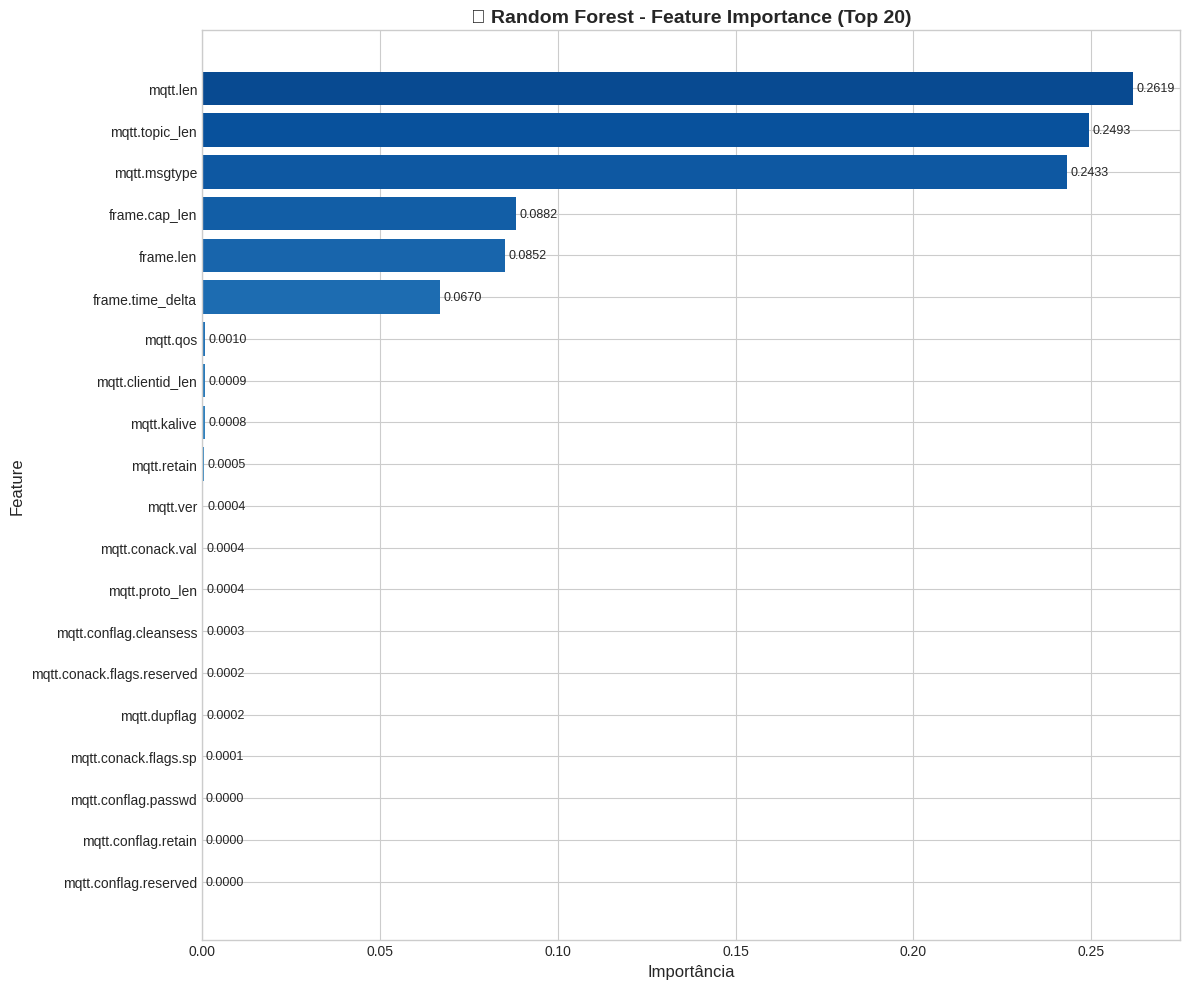

In [8]:
# Visualizar Feature Importance - Random Forest
fig, ax = plt.subplots(figsize=(12, 10))

top_n = 20
rf_top = rf_importance.head(top_n)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax.barh(rf_top['feature'], rf_top['importance'], color=colors)

ax.set_xlabel('Importância', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('🌲 Random Forest - Feature Importance (Top 20)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Adicionar valores nas barras
for bar, val in zip(bars, rf_top['importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Feature Importance com XGBoost

O XGBoost oferece múltiplas métricas de importância:
- **weight**: número de vezes que a feature é usada em splits
- **gain**: ganho médio ao usar a feature
- **cover**: cobertura média das amostras

In [12]:
if XGBOOST_AVAILABLE:
    print("🚀 Treinando XGBoost...")
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=10,
        learning_rate=0.1,
        random_state=42,
        n_jobs=-1,
        use_label_encoder=False,
        eval_metric='mlogloss'
    )
    xgb_model.fit(X_train, y_train)
    
    # Calcular acurácia
    xgb_accuracy = xgb_model.score(X_test, y_test)
    print(f"✅ Acurácia XGBoost: {xgb_accuracy:.4f}")
    
    # Extrair feature importance
    xgb_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(f"\n🏆 Top 15 Features (XGBoost):")
    print(xgb_importance.head(15).to_string(index=False))
else:
    print("⚠️ XGBoost não disponível. Instale com: pip install xgboost")

🚀 Treinando XGBoost...
✅ Acurácia XGBoost: 0.9739

🏆 Top 15 Features (XGBoost):
                   feature  importance
                  mqtt.len    0.908477
            mqtt.topic_len    0.059267
             frame.cap_len    0.017524
              mqtt.dupflag    0.007651
              mqtt.msgtype    0.003595
          frame.time_delta    0.002074
               mqtt.kalive    0.000938
         mqtt.clientid_len    0.000472
    mqtt.conflag.cleansess    0.000000
      mqtt.conack.flags.sp    0.000000
           mqtt.conack.val    0.000000
                 frame.len    0.000000
mqtt.conack.flags.reserved    0.000000
        mqtt.conflag.uname    0.000000
       mqtt.conflag.retain    0.000000


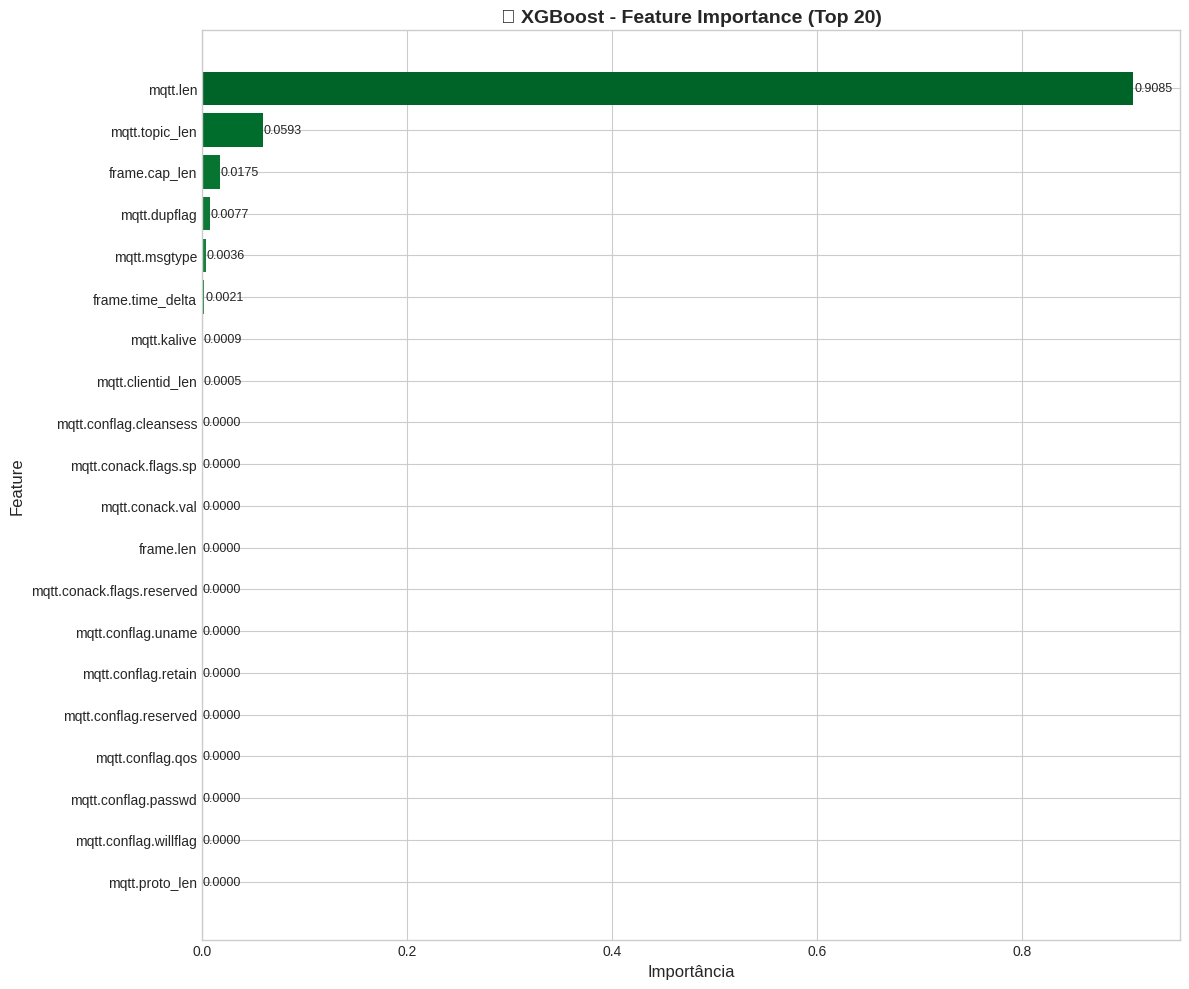

In [13]:
# Visualizar Feature Importance - XGBoost
if XGBOOST_AVAILABLE:
    fig, ax = plt.subplots(figsize=(12, 10))
    
    top_n = 20
    xgb_top = xgb_importance.head(top_n)
    
    colors = plt.cm.Greens(np.linspace(0.4, 0.9, top_n))[::-1]
    bars = ax.barh(xgb_top['feature'], xgb_top['importance'], color=colors)
    
    ax.set_xlabel('Importância', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_title('🚀 XGBoost - Feature Importance (Top 20)', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    
    # Adicionar valores nas barras
    for bar, val in zip(bars, xgb_top['importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()

## 6. Permutation Importance

A **Permutation Importance** mede a importância de uma feature ao verificar quanto a performance do modelo cai quando essa feature é embaralhada. É uma métrica **model-agnostic** e menos enviesada que feature_importances_.

In [14]:
# Calcular Permutation Importance (usando Random Forest)
print("🔀 Calculando Permutation Importance...")
print("⏳ Isso pode levar alguns minutos...")

perm_importance = permutation_importance(
    rf_model, X_test, y_test, 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

# Criar DataFrame com resultados
perm_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print(f"\n🏆 Top 15 Features (Permutation Importance):")
print(perm_importance_df.head(15).to_string(index=False))

🔀 Calculando Permutation Importance...
⏳ Isso pode levar alguns minutos...

🏆 Top 15 Features (Permutation Importance):
                   feature  importance_mean  importance_std
                  mqtt.len         0.042363        0.000968
             frame.cap_len         0.039897        0.000801
                 frame.len         0.026339        0.000732
          frame.time_delta         0.025278        0.000430
              mqtt.msgtype         0.003470        0.000106
            mqtt.topic_len         0.001853        0.000300
               mqtt.kalive         0.000624        0.000028
mqtt.conack.flags.reserved         0.000007        0.000021
      mqtt.conack.flags.sp         0.000007        0.000021
    mqtt.conflag.cleansess         0.000004        0.000011
            mqtt.proto_len         0.000004        0.000011
       mqtt.conflag.passwd         0.000000        0.000000
       mqtt.conflag.retain         0.000000        0.000000
          mqtt.willmsg_len         0.000

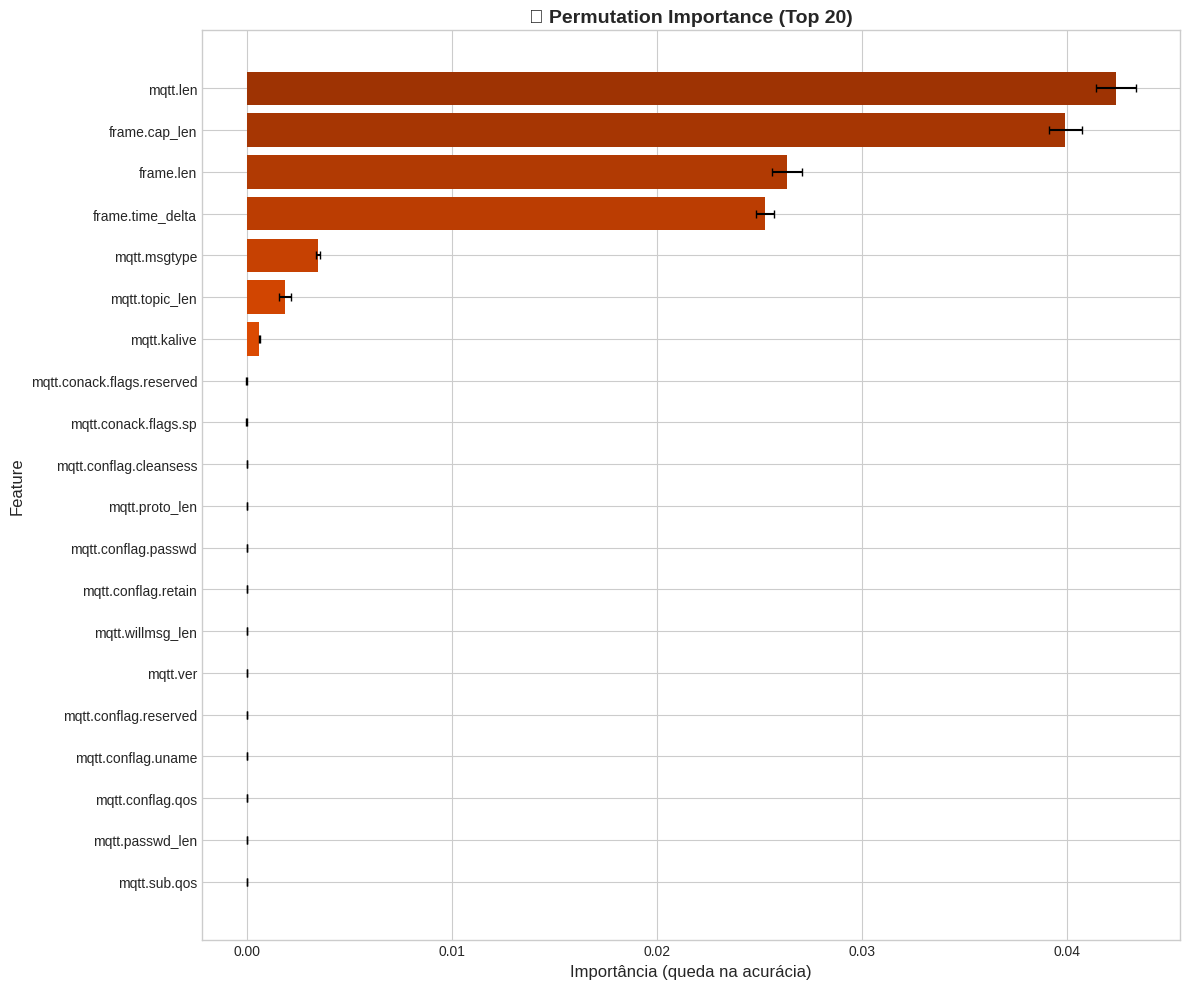

In [15]:
# Visualizar Permutation Importance
fig, ax = plt.subplots(figsize=(12, 10))

top_n = 20
perm_top = perm_importance_df.head(top_n)

colors = plt.cm.Oranges(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax.barh(perm_top['feature'], perm_top['importance_mean'], 
               xerr=perm_top['importance_std'], color=colors, capsize=3)

ax.set_xlabel('Importância (queda na acurácia)', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_title('🔀 Permutation Importance (Top 20)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 7. Comparação dos Métodos

Vamos comparar os rankings de features entre os diferentes métodos para identificar quais features são **consistentemente importantes**.

In [16]:
# Criar ranking comparativo
def create_ranking(df, col='importance'):
    df = df.copy()
    df['rank'] = range(1, len(df) + 1)
    return df.set_index('feature')['rank']

# Rankings de cada método
rf_rank = create_ranking(rf_importance)
perm_rank = create_ranking(perm_importance_df, 'importance_mean')

if XGBOOST_AVAILABLE:
    xgb_rank = create_ranking(xgb_importance)
    
    # Combinar rankings
    comparison_df = pd.DataFrame({
        'RF_rank': rf_rank,
        'XGB_rank': xgb_rank,
        'Perm_rank': perm_rank
    })
    comparison_df['mean_rank'] = comparison_df.mean(axis=1)
else:
    comparison_df = pd.DataFrame({
        'RF_rank': rf_rank,
        'Perm_rank': perm_rank
    })
    comparison_df['mean_rank'] = comparison_df.mean(axis=1)

# Ordenar por ranking médio
comparison_df = comparison_df.sort_values('mean_rank')

print("📊 Comparação de Rankings (Top 20):")
print(comparison_df.head(20).to_string())

📊 Comparação de Rankings (Top 20):
                            RF_rank  XGB_rank  Perm_rank  mean_rank
feature                                                            
mqtt.len                          1         1          1   1.000000
frame.cap_len                     4         3          2   3.000000
mqtt.topic_len                    2         2          6   3.333333
mqtt.msgtype                      3         5          5   4.333333
frame.time_delta                  6         6          4   5.333333
frame.len                         5        12          3   6.666667
mqtt.kalive                       9         7          7   7.666667
mqtt.conflag.cleansess           14         9         10  11.000000
mqtt.conack.flags.reserved       15        13          8  12.000000
mqtt.conack.flags.sp             17        10          9  12.000000
mqtt.proto_len                   13        20         11  14.666667
mqtt.clientid_len                 8         8         28  14.666667
mqtt.dupflag 

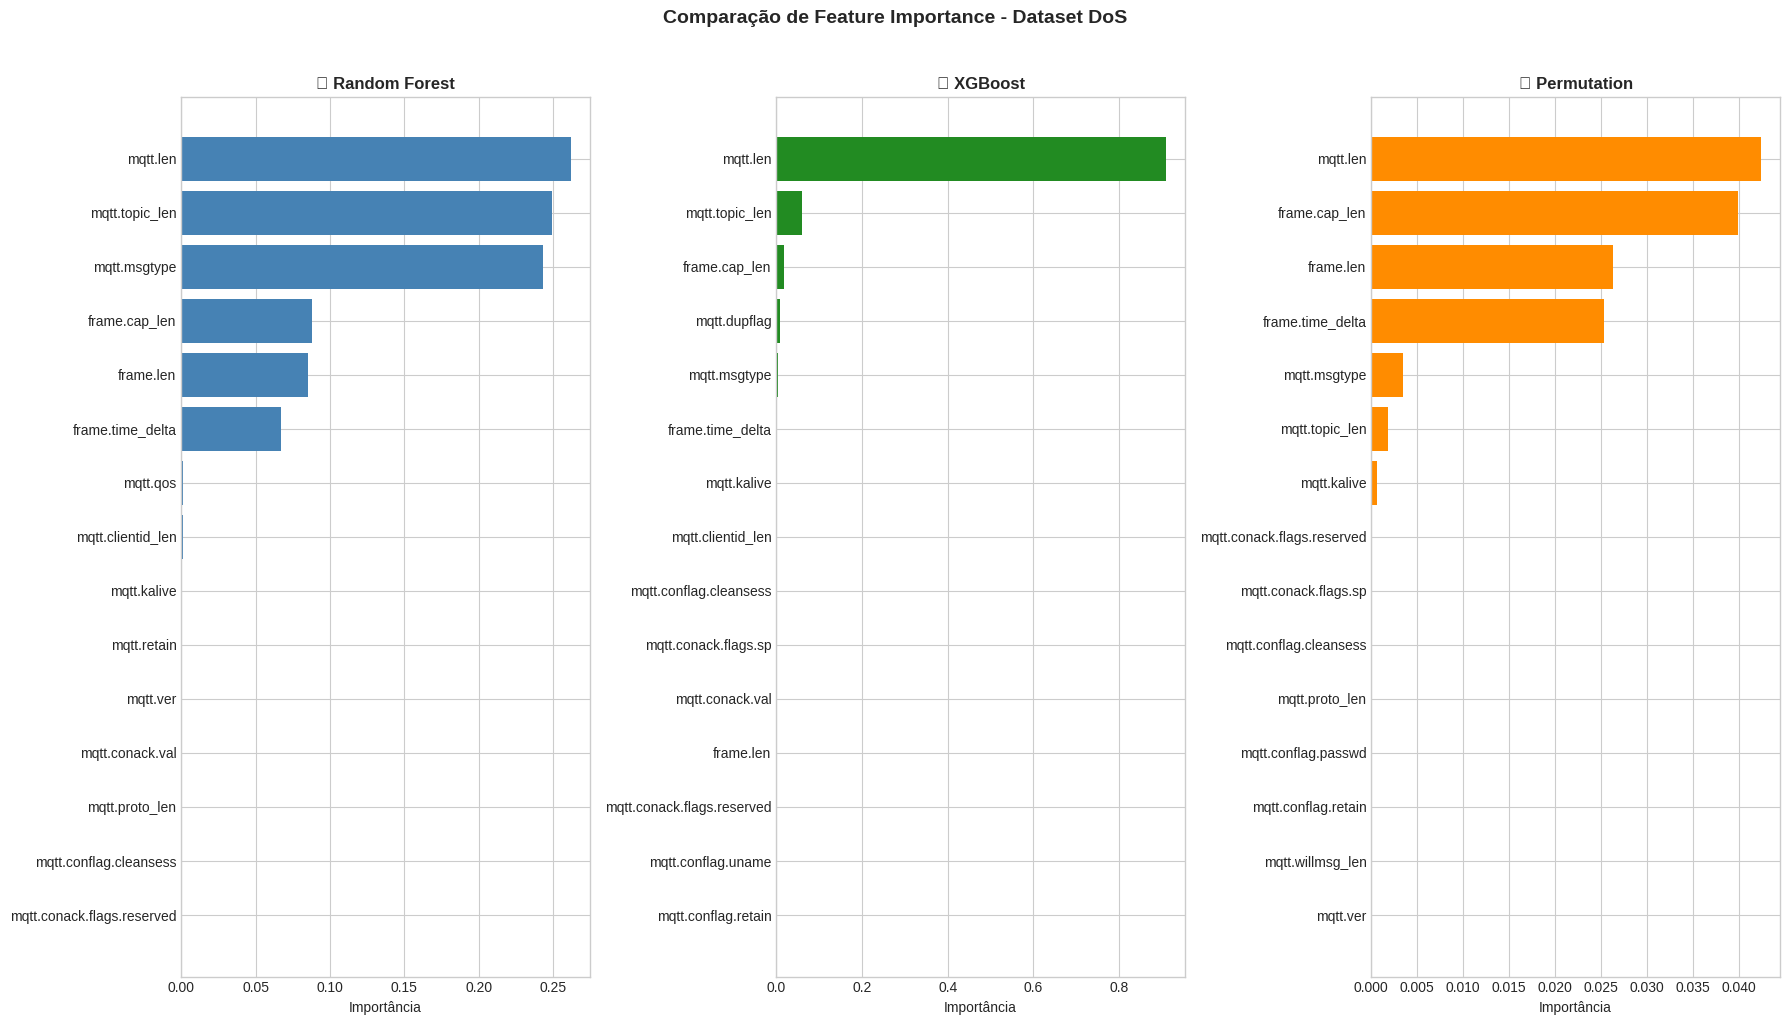

In [17]:
# Visualizar comparação lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 10))

top_n = 15

# Random Forest
rf_top = rf_importance.head(top_n)
axes[0].barh(rf_top['feature'], rf_top['importance'], color='steelblue')
axes[0].set_title('🌲 Random Forest', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Importância')

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_top = xgb_importance.head(top_n)
    axes[1].barh(xgb_top['feature'], xgb_top['importance'], color='forestgreen')
    axes[1].set_title('🚀 XGBoost', fontsize=12, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Importância')
else:
    axes[1].text(0.5, 0.5, 'XGBoost não disponível', ha='center', va='center')
    axes[1].set_title('🚀 XGBoost', fontsize=12, fontweight='bold')

# Permutation Importance
perm_top = perm_importance_df.head(top_n)
axes[2].barh(perm_top['feature'], perm_top['importance_mean'], color='darkorange')
axes[2].set_title('🔀 Permutation', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()
axes[2].set_xlabel('Importância')

plt.suptitle('Comparação de Feature Importance - Dataset DoS', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 8. Identificar Features Mais Importantes

Com base na análise comparativa, identificamos as **features mais relevantes** para detecção de ataques DoS.

In [18]:
# Top features por ranking médio
top_features = comparison_df.head(20).index.tolist()

print("🏆 TOP 20 Features mais importantes (ranking médio):")
for i, feat in enumerate(top_features, 1):
    print(f"  {i:2d}. {feat}")

# Exportar para CSV
output_path = Path("../reports/feature_importance_dos.csv")
comparison_df.to_csv(output_path)
print(f"\n💾 Rankings exportados para: {output_path}")

🏆 TOP 20 Features mais importantes (ranking médio):
   1. mqtt.len
   2. frame.cap_len
   3. mqtt.topic_len
   4. mqtt.msgtype
   5. frame.time_delta
   6. frame.len
   7. mqtt.kalive
   8. mqtt.conflag.cleansess
   9. mqtt.conack.flags.reserved
  10. mqtt.conack.flags.sp
  11. mqtt.proto_len
  12. mqtt.clientid_len
  13. mqtt.dupflag
  14. mqtt.conflag.retain
  15. mqtt.conack.val
  16. mqtt.conflag.passwd
  17. mqtt.conflag.reserved
  18. mqtt.ver
  19. mqtt.conflag.uname
  20. mqtt.conflag.qos

💾 Rankings exportados para: ../reports/feature_importance_dos.csv


## 9. Conclusão

### Métodos utilizados:
1. **Random Forest Feature Importance**: Baseado na redução média de impureza (Gini)
2. **XGBoost Feature Importance**: Baseado no ganho médio nas splits
3. **Permutation Importance**: Baseado na queda de performance ao embaralhar features

